In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
!wget https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt

--2026-03-18 11:44:39--  https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt’

names.txt           100%[===================>] 222.80K  --.-KB/s    in 0.02s   

2026-03-18 11:44:39 (11.7 MB/s) - ‘names.txt’ saved [228145/228145]



In [4]:
with open("names.txt", "r") as f:
  words = [line.strip() for line in f]

print(len(words))
words[:10]


32033


['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [5]:
def char_to_idx(c):
  return 0 if c == "." else (ord(c) - ord('a') + 1)

def idx_to_char(idx):
  return '.' if idx == 0 else chr(ord('a') + idx - 1)

In [6]:
def build_dataset(words):
  X, Y = [], []
  block_size = 3

  for word in words:
    context = [0]*block_size
    word = f"{word}."
    for char in word:
      X.append(context)
      idx = char_to_idx(char)
      Y.append(idx)
      context = context[1:] + [idx]

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

In [7]:
import random
random.seed(42)
random.shuffle(words)

split_train = int(0.8 * len(words))
split_val = int(0.9 * len(words))
X_tr, Y_tr = build_dataset(words[:split_train])
X_val, Y_val = build_dataset(words[split_train:split_val])
X_test, Y_test = build_dataset(words[split_val:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [8]:
# MLP
n_embd = 10
n_hidden = 200
vocab_size = 27
block_size = 3

g = torch.Generator().manual_seed(2147483647) # for reproducibility

# params
C  = torch.randn(vocab_size, n_embd, dtype=torch.float64, generator=g)
W1 = torch.randn(n_embd*block_size, n_hidden, dtype=torch.float64, generator=g)
b1 = torch.randn(n_hidden, dtype=torch.float64, generator=g)
W2 = torch.randn(n_hidden, vocab_size, dtype=torch.float64, generator=g)
b2 = torch.randn(vocab_size, dtype=torch.float64, generator=g)

parameters = [C, W1, b1, W2, b2]
total_params = sum([p.nelement() for p in parameters])
print(f"Total params: {total_params}")
for param in parameters:
  param.requires_grad = True

Total params: 11897


In [9]:
max_steps = 200_000
batch_size = 32
lossi = []

for i in range(max_steps):
  # minibatch construct
  ix = torch.randint(0, X_tr.shape[0], (batch_size,), generator=g)
  Xb, Yb = X_tr[ix], Y_tr[ix]

  emb = C[Xb]                           # [32, 3, 10]
  embcat = emb.view(batch_size, -1)     # [32, 30]
  # Linear Layer
  hpreact = embcat @ W1 + b1            # [32, 30] @ [30, 200] -> [32, 200]
  # Non Linearity
  h = torch.tanh(hpreact)               # [32, 200]
  # Linear Layer
  logits = h @ W2 + b2                  # [32, 200] @ [200, 27] -> [32, 27]
  loss = F.cross_entropy(logits, Yb)



  # Backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # Update
  lr = 0.1 if i < 100_000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  if i % 10_000 == 0:
    print(f"{i}/{max_steps} : {loss.item():.4f}")
  lossi.append(loss.item())

0/200000 : 26.7880
10000/200000 : 2.2907
20000/200000 : 2.9422
30000/200000 : 2.2115
40000/200000 : 2.0762
50000/200000 : 2.1165
60000/200000 : 2.3133
70000/200000 : 2.0370
80000/200000 : 2.0811
90000/200000 : 2.4604
100000/200000 : 2.3307
110000/200000 : 2.2148
120000/200000 : 2.2780
130000/200000 : 2.0014
140000/200000 : 2.1667
150000/200000 : 2.5863
160000/200000 : 2.3715
170000/200000 : 1.9919
180000/200000 : 2.5360
190000/200000 : 1.8959


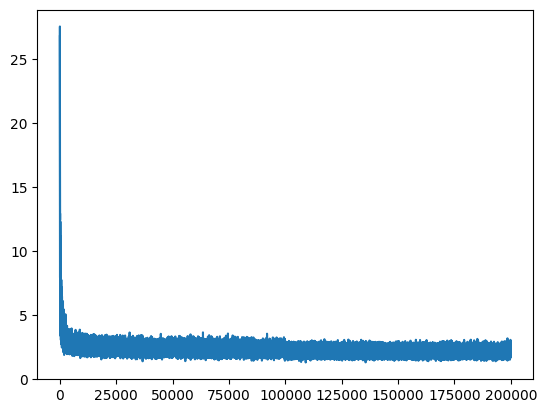

In [10]:
plt.plot(lossi)

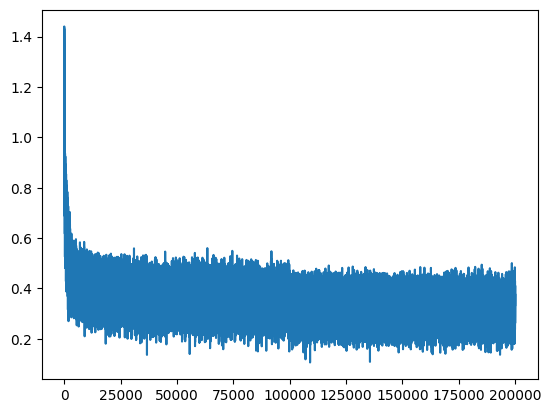

In [11]:
import math
loglossi = [math.log(li, 10) for li in lossi]
plt.plot(loglossi)

In [12]:
SPLITS = {
    'train': (X_tr, Y_tr),
    'val': (X_val, Y_val),
    'test': (X_test, Y_test)
}
@torch.no_grad
def calc_split_loss(split):
  X, Y = SPLITS[split]

  emb = C[X]
  embcat = emb.view(X.shape[0], -1)
  hpreact = embcat @ W1 + b1
  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Y)
  print(f"Split: {split} Loss: {loss: .4f}")

calc_split_loss('train')
calc_split_loss('val')


Split: train Loss:  2.1209
Split: val Loss:  2.1612


### Observation
We can see that initial loss is quite high (**HOCKEY STICK** shape) and initial cycles of training are being wasted because of bad initialization of the parameters.
This means we should do a better job at initialization of parameters.

In [13]:
## Knowing the loss function, we should be able to estimate the initial loss function
## For example for the initial runs,
#  we can expect the model to output each character with equal probability i.e. 1/27

loss1 = -torch.tensor(1/27).log()
loss1 # 3.29 (expected) vs 23 (observed)

tensor(3.2958)

In [14]:
## Other examples
# Assuming index [2] is correct answer
logits1 = torch.tensor([13.0, -5.0, 0.0, -2.0])
probs1 = F.softmax(logits1, dim=0)
-probs1[2].log()

tensor(13.0000)

In [15]:
# Compare this with above (Numbers are relatively closer to each other)
logits1 = torch.tensor([-1.0, -0.5, 0.15, 0.09])
probs1 = F.softmax(logits1, dim=0)
-probs1[2].log()

tensor(1.0226)

Seeing the examples above its quite clear that the parameters **W2** and **b2** need to be closer to 0 to bring the logits closer to zero

In [16]:
# BEFORE : Initial logits
# MLP
n_embd = 10
n_hidden = 200
vocab_size = 27
block_size = 3

g = torch.Generator().manual_seed(2147483647) # for reproducibility

# params
C  = torch.randn(vocab_size, n_embd, dtype=torch.float64, generator=g)
W1 = torch.randn(n_embd*block_size, n_hidden, dtype=torch.float64, generator=g)
b1 = torch.randn(n_hidden, dtype=torch.float64, generator=g)
W2 = torch.randn(n_hidden, vocab_size, dtype=torch.float64, generator=g)
b2 = torch.randn(vocab_size, dtype=torch.float64, generator=g)

parameters = [C, W1, b1, W2, b2]
total_params = sum([p.nelement() for p in parameters])

for param in parameters:
  param.requires_grad = True


max_steps = 200_000
batch_size = 32
lossi = []

for i in range(max_steps):
  # minibatch construct
  ix = torch.randint(0, X_tr.shape[0], (batch_size,), generator=g)
  Xb, Yb = X_tr[ix], Y_tr[ix]

  emb = C[Xb]                           # [32, 3, 10]
  embcat = emb.view(batch_size, -1)     # [32, 30]
  # Linear Layer
  hpreact = embcat @ W1 + b1            # [32, 30] @ [30, 200] -> [32, 200]
  # Non Linearity
  h = torch.tanh(hpreact)               # [32, 200]
  # Linear Layer
  logits = h @ W2 + b2                  # [32, 200] @ [200, 27] -> [32, 27]
  loss = F.cross_entropy(logits, Yb)

  # Backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # Update
  lr = 0.1 if i < 100_000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  if i % 10_000 == 0:
    print(f"{i}/{max_steps} : {loss.item():.4f}")
  lossi.append(loss.item())

  break

print(logits[0]) # Logits for first example
print(lossi[0])

0/200000 : 26.7880
tensor([  1.1845,   9.1600, -15.2538,  -6.0322,  -7.9136,  -1.9282,  -1.8398,
        -10.5319,  -1.2267,  -0.5369,   1.6752, -15.6664, -18.1686,  20.9008,
         -3.1572,   1.8856, -15.0725,   3.6780,  32.8195, -12.9050,   0.6458,
          5.8379, -11.7413,   2.3084,  24.1636,  -5.5190, -30.6603],
       dtype=torch.float64, grad_fn=<SelectBackward0>)
26.787986353509176


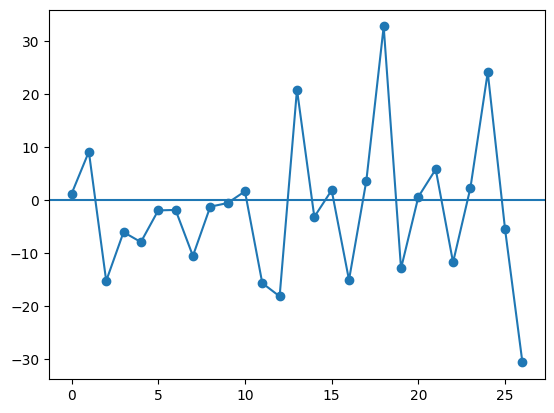

In [17]:
plt.plot(logits[0].detach().numpy(), marker='o')
plt.axhline(0)
plt.show()

As we can observe above, the logits are quite apart from zero line

In [18]:
### AFTER modifying W2 and b2

# MLP
n_embd = 10
n_hidden = 200
vocab_size = 27
block_size = 3

g = torch.Generator().manual_seed(2147483647) # for reproducibility

# params
C  = torch.randn(vocab_size, n_embd, dtype=torch.float64, generator=g)
W1 = torch.randn(n_embd*block_size, n_hidden, dtype=torch.float64, generator=g)
b1 = torch.randn(n_hidden, dtype=torch.float64, generator=g)
W2 = torch.randn(n_hidden, vocab_size, dtype=torch.float64, generator=g) * 0.01
b2 = torch.randn(vocab_size, dtype=torch.float64, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
total_params = sum([p.nelement() for p in parameters])

for param in parameters:
  param.requires_grad = True


max_steps = 200_000
batch_size = 32
lossi = []

for i in range(max_steps):
  # minibatch construct
  ix = torch.randint(0, X_tr.shape[0], (batch_size,), generator=g)
  Xb, Yb = X_tr[ix], Y_tr[ix]

  emb = C[Xb]                           # [32, 3, 10]
  embcat = emb.view(batch_size, -1)     # [32, 30]
  # Linear Layer
  hpreact = embcat @ W1 + b1            # [32, 30] @ [30, 200] -> [32, 200]
  # Non Linearity
  h = torch.tanh(hpreact)               # [32, 200]
  # Linear Layer
  logits = h @ W2 + b2                  # [32, 200] @ [200, 27] -> [32, 27]
  loss = F.cross_entropy(logits, Yb)

  # Backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # Update
  lr = 0.1 if i < 100_000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  if i % 10_000 == 0:
    print(f"{i}/{max_steps} : {loss.item():.4f}")
  lossi.append(loss.item())

  break

print(logits[0]) # Logits for first example
print(lossi[0])

0/200000 : 3.2989
tensor([ 0.0074,  0.0871, -0.1161, -0.0669, -0.0812, -0.0073, -0.0101, -0.1023,
        -0.0262, -0.0049,  0.0263, -0.1370, -0.1810,  0.2028, -0.0372,  0.0103,
        -0.1822,  0.0266,  0.3235, -0.1485,  0.0064,  0.0442, -0.1135,  0.0213,
         0.2461, -0.0541, -0.3142], dtype=torch.float64,
       grad_fn=<SelectBackward0>)
3.298939126107121


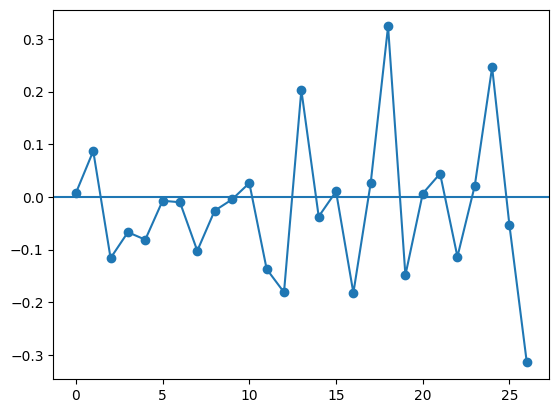

In [19]:
plt.plot(logits[0].detach().numpy(), marker='o')
plt.axhline(0)
plt.show()

In [20]:
## Doing full training now with improved weights

### AFTER modifying W2 and b2

# MLP
n_embd = 10
n_hidden = 200
vocab_size = 27
block_size = 3

g = torch.Generator().manual_seed(2147483647) # for reproducibility

# params
C  = torch.randn(vocab_size, n_embd, dtype=torch.float64, generator=g)
W1 = torch.randn(n_embd*block_size, n_hidden, dtype=torch.float64, generator=g)
b1 = torch.randn(n_hidden, dtype=torch.float64, generator=g)
W2 = torch.randn(n_hidden, vocab_size, dtype=torch.float64, generator=g) * 0.01
b2 = torch.randn(vocab_size, dtype=torch.float64, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
total_params = sum([p.nelement() for p in parameters])

for param in parameters:
  param.requires_grad = True


max_steps = 200_000
batch_size = 32
lossi = []

for i in range(max_steps):
  # minibatch construct
  ix = torch.randint(0, X_tr.shape[0], (batch_size,), generator=g)
  Xb, Yb = X_tr[ix], Y_tr[ix]

  emb = C[Xb]                           # [32, 3, 10]
  embcat = emb.view(batch_size, -1)     # [32, 30]
  # Linear Layer
  hpreact = embcat @ W1 + b1            # [32, 30] @ [30, 200] -> [32, 200]
  # Non Linearity
  h = torch.tanh(hpreact)               # [32, 200]
  # Linear Layer
  logits = h @ W2 + b2                  # [32, 200] @ [200, 27] -> [32, 27]
  loss = F.cross_entropy(logits, Yb)

  # Backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # Update
  lr = 0.1 if i < 100_000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  if i % 10_000 == 0:
    print(f"{i}/{max_steps} : {loss.item():.4f}")
  lossi.append(loss.item())

0/200000 : 3.2989
10000/200000 : 2.0936
20000/200000 : 2.3649
30000/200000 : 2.3388
40000/200000 : 2.0901
50000/200000 : 2.0401
60000/200000 : 2.2954
70000/200000 : 2.2010
80000/200000 : 2.0698
90000/200000 : 2.2630
100000/200000 : 2.2093
110000/200000 : 2.2344
120000/200000 : 2.1734
130000/200000 : 1.9922
140000/200000 : 2.0925
150000/200000 : 2.7634
160000/200000 : 2.2795
170000/200000 : 1.9141
180000/200000 : 2.3817
190000/200000 : 1.9736


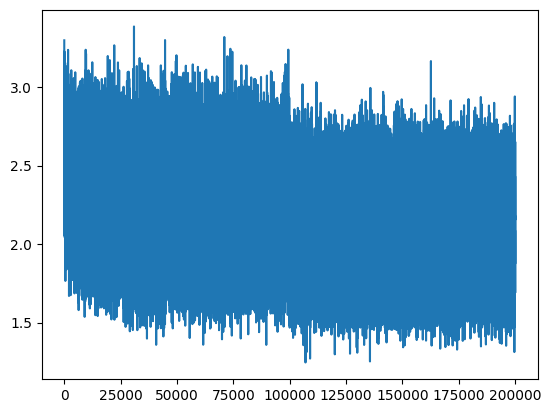

In [21]:
plt.plot(lossi)

In [22]:
calc_split_loss('train')
calc_split_loss('val')

Split: train Loss:  2.0662
Split: val Loss:  2.1313


### OBSERVATION
- No initial high loss

- We can see that final loss is way lower now because of no initial training cycles wasted because of bad initialization

- train *2.06* vs *2.12*
- val *2.13* vs *2.16*

## NEXT: Analyzing preactivations and post activations

In [23]:
### AFTER modifying W2 and b2

# MLP
n_embd = 10
n_hidden = 200
vocab_size = 27
block_size = 3

g = torch.Generator().manual_seed(2147483647) # for reproducibility

# params
C  = torch.randn(vocab_size, n_embd, dtype=torch.float64, generator=g)
W1 = torch.randn(n_embd*block_size, n_hidden, dtype=torch.float64, generator=g)
b1 = torch.randn(n_hidden, dtype=torch.float64, generator=g)
W2 = torch.randn(n_hidden, vocab_size, dtype=torch.float64, generator=g) * 0.01
b2 = torch.randn(vocab_size, dtype=torch.float64, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
total_params = sum([p.nelement() for p in parameters])

for param in parameters:
  param.requires_grad = True


max_steps = 200_000
batch_size = 32
lossi = []

for i in range(max_steps):
  # minibatch construct
  ix = torch.randint(0, X_tr.shape[0], (batch_size,), generator=g)
  Xb, Yb = X_tr[ix], Y_tr[ix]

  emb = C[Xb]                           # [32, 3, 10]
  embcat = emb.view(batch_size, -1)     # [32, 30]
  # Linear Layer
  hpreact = embcat @ W1 + b1            # [32, 30] @ [30, 200] -> [32, 200]
  # Non Linearity
  h = torch.tanh(hpreact)               # [32, 200]
  # Linear Layer
  logits = h @ W2 + b2                  # [32, 200] @ [200, 27] -> [32, 27]
  loss = F.cross_entropy(logits, Yb)

  # Backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # Update
  lr = 0.1 if i < 100_000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  if i % 10_000 == 0:
    print(f"{i}/{max_steps} : {loss.item():.4f}")
  lossi.append(loss.item())

  break # Just 1st iteration

0/200000 : 3.2989


(array([0.00016987, 0.00016987, 0.00033974, 0.00033974, 0.00016987,
        0.00067949, 0.00135897, 0.00135897, 0.00288782, 0.00475641,
        0.00730449, 0.00798397, 0.01104166, 0.01545833, 0.01919551,
        0.02174358, 0.02497115, 0.03737178, 0.04671473, 0.0511314 ,
        0.05333973, 0.06438139, 0.06030447, 0.06540062, 0.06879806,
        0.07338459, 0.06523075, 0.06692947, 0.05724678, 0.04909294,
        0.04076922, 0.04263781, 0.0300673 , 0.0246314 , 0.01749679,
        0.01375961, 0.01121154, 0.00798397, 0.00577564, 0.00441667,
        0.00271795, 0.00220833, 0.00203846, 0.00067949, 0.00101923,
        0.        , 0.00016987, 0.00016987, 0.        , 0.00016987]),
 array([-22.66765586, -21.74784428, -20.82803271, -19.90822113,
        -18.98840955, -18.06859798, -17.1487864 , -16.22897482,
        -15.30916325, -14.38935167, -13.46954009, -12.54972852,
        -11.62991694, -10.71010536,  -9.79029379,  -8.87048221,
         -7.95067063,  -7.03085905,  -6.11104748,  -5.1912359 

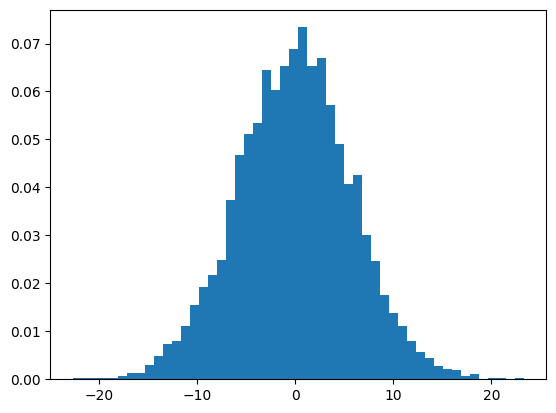

In [24]:
# Plotting histogram of hpreact
plt.hist(hpreact.view(-1).tolist(), bins=50, density=True)

(array([9.34765625, 0.48828125, 0.359375  , 0.22265625, 0.25390625,
        0.125     , 0.13671875, 0.14453125, 0.1015625 , 0.12109375,
        0.12109375, 0.06640625, 0.10546875, 0.08203125, 0.0390625 ,
        0.06640625, 0.078125  , 0.06640625, 0.08984375, 0.0546875 ,
        0.09375   , 0.05078125, 0.10546875, 0.05859375, 0.078125  ,
        0.0703125 , 0.0625    , 0.0625    , 0.08984375, 0.0859375 ,
        0.0546875 , 0.07421875, 0.09375   , 0.0625    , 0.11328125,
        0.08984375, 0.1015625 , 0.11328125, 0.0703125 , 0.109375  ,
        0.0859375 , 0.12109375, 0.14453125, 0.15625   , 0.18359375,
        0.26953125, 0.3046875 , 0.37109375, 0.5390625 , 9.11328125]),
 array([-1.  , -0.96, -0.92, -0.88, -0.84, -0.8 , -0.76, -0.72, -0.68,
        -0.64, -0.6 , -0.56, -0.52, -0.48, -0.44, -0.4 , -0.36, -0.32,
        -0.28, -0.24, -0.2 , -0.16, -0.12, -0.08, -0.04,  0.  ,  0.04,
         0.08,  0.12,  0.16,  0.2 ,  0.24,  0.28,  0.32,  0.36,  0.4 ,
         0.44,  0.48,  0.52,  0.56

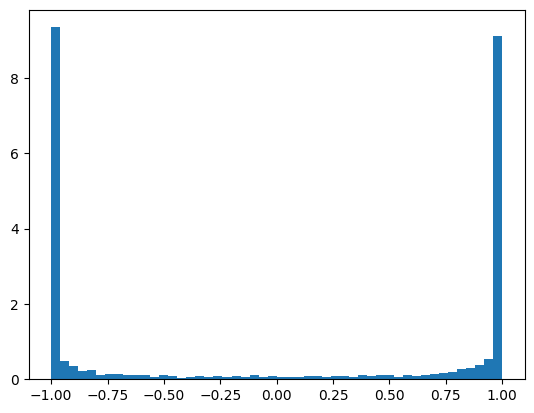

In [25]:
# Plotting histogram of h
plt.hist(h.view(-1).tolist(), bins=50, density=True)

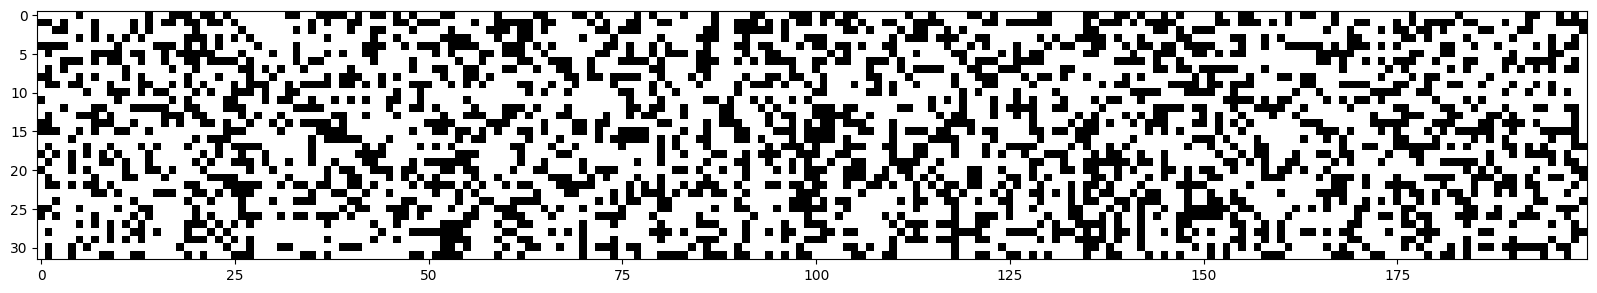

In [26]:
plt.figure(figsize=(20,400))
data = (h.abs() > 0.99)
plt.imshow(data, cmap='gray') #[32, 200] 32 examples and 200 neurons

### Observations based on plots above
We can see that
- a lot of activations are falling in category of 1 and -1
and since local gradient for that is zero, that means the neurons basically don't pass the gradients further back hence impacting efficient weight updates. This impact is seen even more in deeper networks.

Means:  tensor(-0.0044) tensor(0.0036)
Std  :  tensor(1.0034) tensor(4.5192)


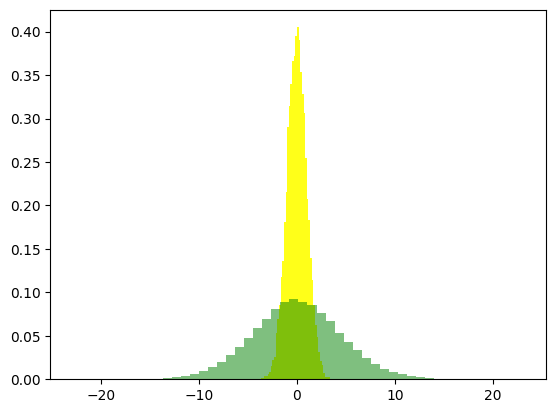

In [27]:
# Understand effect of matrix mul
# Shows effect to w spreading out the initial distribution
# Should ideally be unit gaussian, mean=0, std=1

x = torch.randn(1000, 20)
w = torch.randn(20, 200)
y = x @ w
print("Means: ", x.mean(), y.mean())
print("Std  : ", x.std(), y.std())

plt.hist(x.view(-1).tolist(), bins=50, density=True, color='yellow', alpha=0.9)
plt.hist(y.view(-1).tolist(), bins=50, density=True, color='green', alpha=0.5)
plt.show()

Means:  tensor(-0.0020) tensor(0.0003)
Std  :  tensor(1.0039) tensor(0.8860)


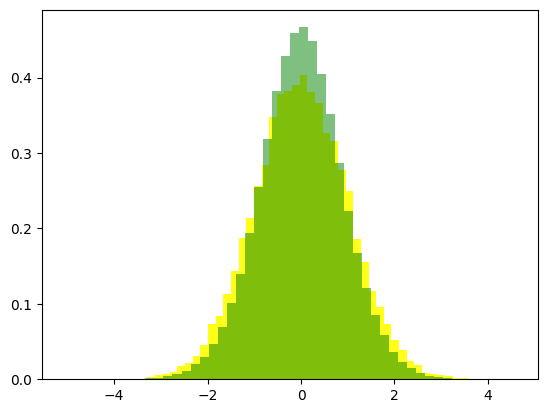

In [28]:
# Making w smaller to not spread x too much
# output close to unit gaussian

x = torch.randn(1000, 20)
w = torch.randn(20, 200) * 0.2
y = x @ w
print("Means: ", x.mean(), y.mean())
print("Std  : ", x.std(), y.std())

plt.hist(x.view(-1).tolist(), bins=50, density=True, color='yellow', alpha=0.9)
plt.hist(y.view(-1).tolist(), bins=50, density=True, color='green', alpha=0.5)
plt.show()

Means:  tensor(0.0070) tensor(0.0013)
Std  :  tensor(1.0022) tensor(0.9982)


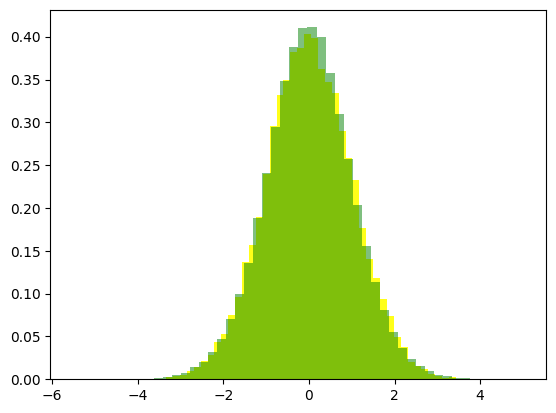

In [29]:
# Using kaiming he initializer
std = 1/(20**0.5)

x = torch.randn(1000, 20)
w = torch.randn(20, 200) * std
y = x @ w
print("Means: ", x.mean(), y.mean())
print("Std  : ", x.std(), y.std())

plt.hist(x.view(-1).tolist(), bins=50, density=True, color='yellow', alpha=0.9)
plt.hist(y.view(-1).tolist(), bins=50, density=True, color='green', alpha=0.5)
plt.show()

In [30]:
# Using Kaiming He initializer for better activations
### AFTER modifying W2 and b2

# MLP
n_embd = 10
n_hidden = 200
vocab_size = 27
block_size = 3

g = torch.Generator().manual_seed(2147483647) # for reproducibility

# params
C  = torch.randn(vocab_size, n_embd, dtype=torch.float64, generator=g)
W1 = torch.randn(n_embd*block_size, n_hidden, dtype=torch.float64, generator=g) * ((5/3)/(n_embd*block_size)**0.5)
b1 = torch.randn(n_hidden, dtype=torch.float64, generator=g) * 0
W2 = torch.randn(n_hidden, vocab_size, dtype=torch.float64, generator=g) * 0.01
b2 = torch.randn(vocab_size, dtype=torch.float64, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
total_params = sum([p.nelement() for p in parameters])

for param in parameters:
  param.requires_grad = True


max_steps = 200_000
batch_size = 32
lossi = []

for i in range(max_steps):
  # minibatch construct
  ix = torch.randint(0, X_tr.shape[0], (batch_size,), generator=g)
  Xb, Yb = X_tr[ix], Y_tr[ix]

  emb = C[Xb]                           # [32, 3, 10]
  embcat = emb.view(batch_size, -1)     # [32, 30]
  # Linear Layer
  hpreact = embcat @ W1 + b1            # [32, 30] @ [30, 200] -> [32, 200]
  # Non Linearity
  h = torch.tanh(hpreact)               # [32, 200]
  # Linear Layer
  logits = h @ W2 + b2                  # [32, 200] @ [200, 27] -> [32, 27]
  loss = F.cross_entropy(logits, Yb)

  # Backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # Update
  lr = 0.1 if i < 100_000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  if i % 10_000 == 0:
    print(f"{i}/{max_steps} : {loss.item():.4f}")
  lossi.append(loss.item())

  break # Just 1st iteration

0/200000 : 3.2798


(array([0.00114968, 0.00057484, 0.00057484, 0.00057484, 0.00114968,
        0.00344905, 0.0068981 , 0.0068981 , 0.01322136, 0.01494588,
        0.0275924 , 0.02184399, 0.04598734, 0.05001123, 0.07472942,
        0.07243006, 0.09312436, 0.13106391, 0.15578211, 0.1667041 ,
        0.18222483, 0.20866755, 0.19544619, 0.22418827, 0.22993669,
        0.23740963, 0.23568511, 0.22016438, 0.17877578, 0.15865632,
        0.14486012, 0.12876455, 0.10634572, 0.1005973 , 0.0592087 ,
        0.04311313, 0.03334082, 0.0316163 , 0.02126914, 0.01609557,
        0.01207168, 0.00747294, 0.00632326, 0.00344905, 0.00229937,
        0.00114968, 0.00057484, 0.        , 0.        , 0.00057484]),
 array([-6.67547435, -6.40366041, -6.13184646, -5.86003251, -5.58821856,
        -5.31640461, -5.04459067, -4.77277672, -4.50096277, -4.22914882,
        -3.95733487, -3.68552093, -3.41370698, -3.14189303, -2.87007908,
        -2.59826513, -2.32645119, -2.05463724, -1.78282329, -1.51100934,
        -1.2391954 , -0.96

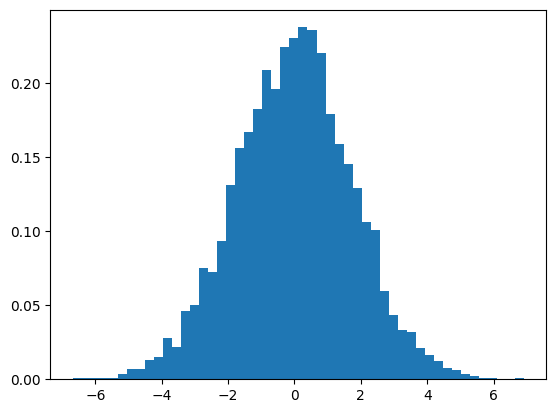

In [31]:
# Plotting histogram of hpreact
plt.hist(hpreact.view(-1).tolist(), bins=50, density=True)

(array([3.28516471, 1.30859712, 0.80859583, 0.72656437, 0.55468893,
        0.43359487, 0.41796983, 0.34765715, 0.47265747, 0.35156341,
        0.2929695 , 0.24218812, 0.27734446, 0.23046934, 0.2734382 ,
        0.30859455, 0.23828186, 0.21875056, 0.2148443 , 0.2343756 ,
        0.25781316, 0.2148443 , 0.23046934, 0.25000064, 0.2343756 ,
        0.195313  , 0.24218812, 0.24609438, 0.26562568, 0.28906324,
        0.19140674, 0.28515698, 0.23828186, 0.25781316, 0.31640707,
        0.2929695 , 0.31250081, 0.31250081, 0.30078202, 0.28515698,
        0.39453227, 0.39843853, 0.41406357, 0.43359487, 0.48828251,
        0.50390755, 0.60547031, 0.82031461, 1.23047192, 3.25391463]),
 array([-9.99996817e-01, -9.59996920e-01, -9.19997023e-01, -8.79997127e-01,
        -8.39997230e-01, -7.99997333e-01, -7.59997436e-01, -7.19997539e-01,
        -6.79997642e-01, -6.39997745e-01, -5.99997848e-01, -5.59997951e-01,
        -5.19998054e-01, -4.79998157e-01, -4.39998260e-01, -3.99998363e-01,
        -3.599

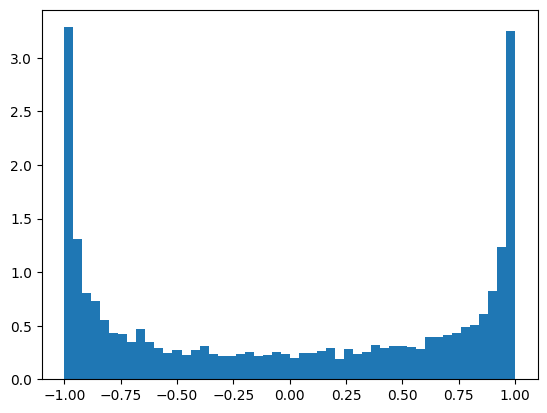

In [32]:
plt.hist(h.view(-1).tolist(), bins=50, density=True)

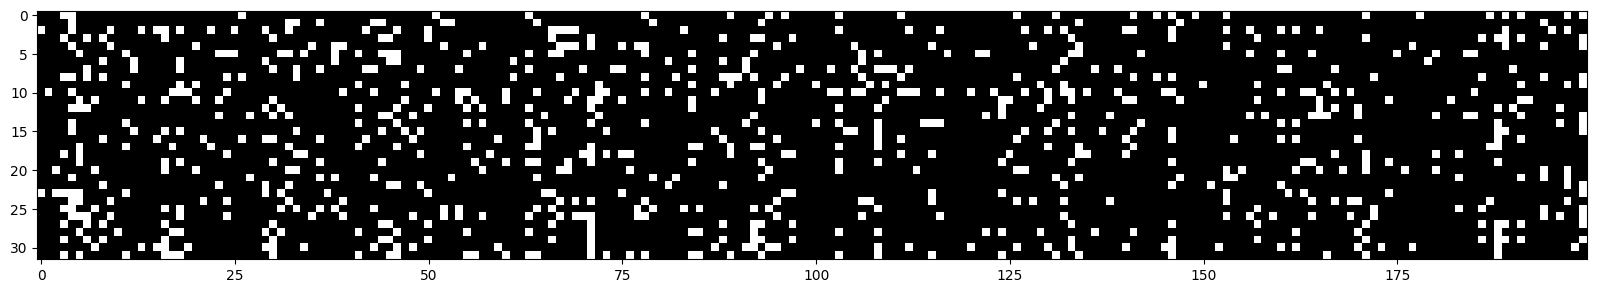

In [33]:
# Looks much darker i.e. less possibility of dead neurons
plt.figure(figsize=(20,400))
data = (h.abs() > 0.99)
plt.imshow(data, cmap='gray') #[32, 200] 32 examples and 200 neurons

In [34]:
### Full training with proper initializing for better activations
# Using Kaiming He initializer for better activations
### AFTER modifying W2 and b2

# MLP
n_embd = 10
n_hidden = 200
vocab_size = 27
block_size = 3

g = torch.Generator().manual_seed(2147483647) # for reproducibility

# params
C  = torch.randn(vocab_size, n_embd, dtype=torch.float64, generator=g)
W1 = torch.randn(n_embd*block_size, n_hidden, dtype=torch.float64, generator=g) * ((5/3)/(n_embd*block_size)**0.5)
b1 = torch.randn(n_hidden, dtype=torch.float64, generator=g) * 0
W2 = torch.randn(n_hidden, vocab_size, dtype=torch.float64, generator=g) * 0.01
b2 = torch.randn(vocab_size, dtype=torch.float64, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
total_params = sum([p.nelement() for p in parameters])

for param in parameters:
  param.requires_grad = True


max_steps = 200_000
batch_size = 32
lossi = []

for i in range(max_steps):
  # minibatch construct
  ix = torch.randint(0, X_tr.shape[0], (batch_size,), generator=g)
  Xb, Yb = X_tr[ix], Y_tr[ix]

  emb = C[Xb]                           # [32, 3, 10]
  embcat = emb.view(batch_size, -1)     # [32, 30]
  # Linear Layer
  hpreact = embcat @ W1 + b1            # [32, 30] @ [30, 200] -> [32, 200]
  # Non Linearity
  h = torch.tanh(hpreact)               # [32, 200]
  # Linear Layer
  logits = h @ W2 + b2                  # [32, 200] @ [200, 27] -> [32, 27]
  loss = F.cross_entropy(logits, Yb)

  # Backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # Update
  lr = 0.1 if i < 100_000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  if i % 10_000 == 0:
    print(f"{i}/{max_steps} : {loss.item():.4f}")
  lossi.append(loss.item())

0/200000 : 3.2798
10000/200000 : 2.0793
20000/200000 : 2.4571
30000/200000 : 2.2309
40000/200000 : 1.9403
50000/200000 : 1.9598
60000/200000 : 2.2407
70000/200000 : 1.9585
80000/200000 : 2.1179
90000/200000 : 2.3132
100000/200000 : 2.1539
110000/200000 : 2.2322
120000/200000 : 2.1195
130000/200000 : 1.9455
140000/200000 : 2.0167
150000/200000 : 2.7288
160000/200000 : 2.2281
170000/200000 : 1.8988
180000/200000 : 2.3838
190000/200000 : 1.8587


In [35]:
calc_split_loss('train')
calc_split_loss('val')

Split: train Loss:  2.0390
Split: val Loss:  2.1068


#### With these changes
No good initialization -> Fixing softmax bad confidence -> Fixing activations
- train *2.12* vs *2.06* vs *2.03*
- val *2.16* vs *2.13* vs *2.10*



### BatchNorm Implementation
Instead of choosing the W1 and b1 carefully to create an approximate unit Gaussian for pre-activations,
create a gaussian yourself using batchnorm
- Unit gaussian is maintained in the first passes but then the scale and shift factor is trainable during backward pass



In [36]:
### Full training
### Using BatchNorm for better activation
### modifying W2 and b2 for better initial losses

# MLP
n_embd = 10
n_hidden = 200
vocab_size = 27
block_size = 3

g = torch.Generator().manual_seed(2147483647) # for reproducibility

# Params
C  = torch.randn(vocab_size, n_embd, dtype=torch.float64, generator=g)
W1 = torch.randn(n_embd*block_size, n_hidden, dtype=torch.float64, generator=g)
bngain = torch.ones((1,n_hidden))
bnbias = torch.zeros((1,n_hidden))
W2 = torch.randn(n_hidden, vocab_size, dtype=torch.float64, generator=g) * 0.01
b2 = torch.randn(vocab_size, dtype=torch.float64, generator=g) * 0

parameters = [C, W1, bngain, bnbias, W2, b2]
total_params = sum([p.nelement() for p in parameters])

for param in parameters:
  param.requires_grad = True

# non-params
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))
momentum = 0.001

max_steps = 200_000
batch_size = 32
lossi = []

for i in range(max_steps):
  # minibatch construct
  ix = torch.randint(0, X_tr.shape[0], (batch_size,), generator=g)
  Xb, Yb = X_tr[ix], Y_tr[ix]

  emb = C[Xb]                           # [32, 3, 10]
  embcat = emb.view(batch_size, -1)     # [32, 30]
  # Linear Layer
  hpreact = embcat @ W1                 # [32, 30] @ [30, 200] -> [32, 200]
  # Batchnorm
  bnmean_batch = hpreact.mean(dim=0)    # [1, 200]
  bnstd_batch = hpreact.std(dim=0)      # [1, 200]
  hpreact = bngain * ((hpreact - bnmean_batch)/bnstd_batch) + bnbias # [1, 200]*[32, 200] + [1, 200]
  with torch.no_grad():
    bnmean_running = (1-momentum)*bnmean_running + momentum*bnmean_batch
    bnstd_running  = (1-momentum)*bnstd_running + momentum*bnstd_batch
  # Non Linearity
  h = torch.tanh(hpreact)               # [32, 200]
  # Output Layer
  logits = h @ W2 + b2                  # [32, 200] @ [200, 27] -> [32, 27]
  loss = F.cross_entropy(logits, Yb)

  # Backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # Update
  lr = 0.1 if i < 100_000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  if i % 10_000 == 0:
    print(f"{i}/{max_steps} : {loss.item():.4f}")
  lossi.append(loss.item())

0/200000 : 3.2847
10000/200000 : 2.1615
20000/200000 : 2.3589
30000/200000 : 2.3879
40000/200000 : 2.2436
50000/200000 : 2.2591
60000/200000 : 2.4178
70000/200000 : 1.8197
80000/200000 : 2.0805
90000/200000 : 2.1455
100000/200000 : 2.4611
110000/200000 : 2.1505
120000/200000 : 2.2568
130000/200000 : 1.7971
140000/200000 : 1.9665
150000/200000 : 2.0931
160000/200000 : 2.4944
170000/200000 : 2.1759
180000/200000 : 2.0175
190000/200000 : 1.7639


In [37]:
# Redefining this to add batchnorm during final loss calculation

SPLITS = {
    'train': (X_tr, Y_tr),
    'val': (X_val, Y_val),
    'test': (X_test, Y_test)
}
@torch.no_grad
def calc_split_loss(split):
  X, Y = SPLITS[split]

  emb = C[X]
  embcat = emb.view(X.shape[0], -1)
  hpreact = embcat @ W1
  hpreact = bngain*((hpreact-bnmean_running)/bnstd_running) + bnbias
  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Y)
  print(f"Split: {split} Loss: {loss: .4f}")

calc_split_loss('train')
calc_split_loss('val')


Split: train Loss:  2.1121
Split: val Loss:  2.1380


Loss
After batchnorm but removing Kaiming He init
- train: 2.11
- val: 2.13

Before batchnorm
- train: *2.12* vs *2.06* vs *2.03*
- val: *2.16* vs *2.13* vs *2.10*

### Exercise 02
BatchNorm, unlike other normalization layers like LayerNorm/GroupNorm etc. has the big advantage that after training, the batchnorm gamma/beta can be "folded into" the weights of the preceeding Linear layers, effectively erasing the need to forward it at test time.

*Set up a small 3-layer MLP with batchnorms, train the network, then "fold" the batchnorm gamma/beta into the preceeding Linear layer's W,b by creating a new W2, b2 and erasing the batch norm. Verify that this gives the same forward pass during inference.*

i.e. we see that the batchnorm is there just for stabilizing the training, and can be thrown out after training is done! pretty cool.

In [38]:
# Redefining this to add batchnorm during final loss calculation
# Also called BATCHNORM FUSION
# bngain -> gamma ; bnbias -> beta
folded_W1 = W1 * (bngain/bnstd_running)
folded_b1 = bnbias - bnmean_running*(bngain/bnstd_running)
# Derivation -> https://chatgpt.com/c/69ba59b9-13d4-8321-ad8d-47ce3aebee9d

SPLITS = {
    'train': (X_tr, Y_tr),
    'val': (X_val, Y_val),
    'test': (X_test, Y_test)
}
@torch.no_grad
def calc_split_loss(split):
  X, Y = SPLITS[split]

  emb = C[X]
  embcat = emb.view(X.shape[0], -1)
  hpreact = embcat @ folded_W1 + folded_b1
  #hpreact = bngain*((hpreact-bnmean_running)/bnstd_running) + bnbias
  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Y)
  print(f"Split: {split} Loss: {loss: .4f}")

calc_split_loss('train')
calc_split_loss('val')


Split: train Loss:  2.1121
Split: val Loss:  2.1380


### Making API similar to Pytorch

In [48]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility

class Linear:
  def __init__(self, in_features, out_features, bias=False):
    self.w = torch.randn(in_features, out_features, dtype=torch.float64, generator=g) / (in_features**0.5)
    if bias:
      self.b = torch.randn(out_features, dtype=torch.float64)
    else:
      self.b = None

  def __call__(self, x):
    self.out = x @ self.w
    if self.b:
      self.out += self.b
    return self.out

  def parameters(self):
    return [self.w]+ ([self.b] if self.b else [])

class BatchNorm1d:
  def __init__(self, num_features, momentum=0.001, training=True):
    self.gain = torch.ones((1, num_features))
    self.bias = torch.zeros((1, num_features))
    self.mean_running = torch.zeros((1, num_features))
    self.std_running = torch.ones((1, num_features))
    self.momentum = momentum
    self.training = training

  def __call__(self, x):
    if self.training: # Use batch mean if training, else use running on inference
      bn_mean = x.mean(dim=0)
      bn_std = x.std(dim=0)
    else:
      bn_mean = self.mean_running
      bn_std = self.std_running
    self.out = self.gain*((x - bn_mean)/bn_std) + self.bias
    if self.training:
      with torch.no_grad():
        self.mean_running = (1-momentum)*self.mean_running + momentum*bn_mean
        self.std_running  = (1-momentum)*self.std_running + momentum*bn_std
    return self.out

  def parameters(self):
    return [self.gain, self.bias]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return []

In [68]:
# MLP
n_embd = 10
n_hidden = 100
vocab_size = 27
block_size = 3

layers = [
    Linear(n_embd*block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size), BatchNorm1d(vocab_size)
]
C  = torch.randn(vocab_size, n_embd, dtype=torch.float64, generator=g)


max_steps = 200_000
batch_size = 32
lossi = []

# Setting parameters to require grad
parameters = [C] + [p for layer in layers for p in layer.parameters()]
for p in parameters:
  p.requires_grad = True

print(sum(p.nelement() for p in parameters)) # number of parameters in total

for i in range(max_steps):
  # minibatch construct
  ix = torch.randint(0, X_tr.shape[0], (batch_size,), generator=g)
  Xb, Yb = X_tr[ix], Y_tr[ix]

  emb = C[Xb]                           # [32, 3, 10]
  out = emb.view(batch_size, -1)        # [32, 30]

  for layer in layers:
    out = layer(out)
  loss = F.cross_entropy(out, Yb)

  # Backward pass
  for layer in layers:
    layer.out.retain_grad() # By default, Pytorch does not retain grads of non-params for efficiency
  for p in parameters:
    p.grad = None
  loss.backward()

  # Update
  lr = 0.1 if i < 100_000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  if i > 1_000:
    break

  if i % 10_000 == 0:
    print(f"{i}/{max_steps} : {loss.item():.4f}")
  lossi.append(loss.item())

47024
0/200000 : 3.8617


#### Visualizations to better understand NN

layer 2 (Tanh): mean:-0.00, std:0.60, saturated:4.81%
layer 5 (Tanh): mean:0.00, std:0.62, saturated:4.00%
layer 8 (Tanh): mean:0.01, std:0.64, saturated:3.19%
layer 11 (Tanh): mean:-0.00, std:0.65, saturated:3.03%
layer 14 (Tanh): mean:0.00, std:0.66, saturated:2.28%


Text(0.5, 1.0, 'Tanh activation distribution')

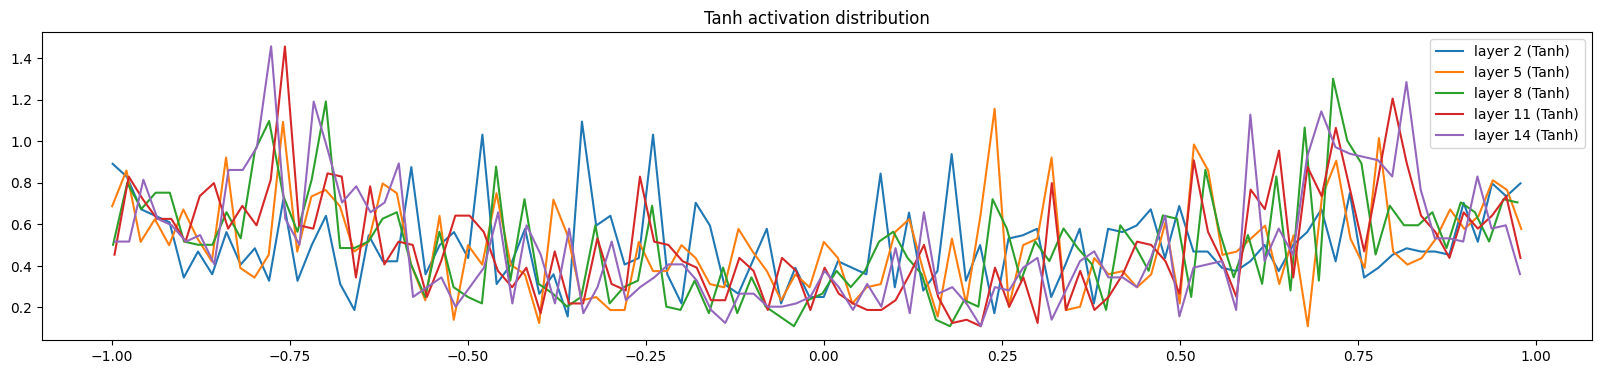

In [69]:
# Tanh Activations/Saturations
# visualize histograms
# Y axis represent probability density, Probability(Area) = density (height) * bin_size
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out # Shape [32, 100]
    layer_name = layer.__class__.__name__
    saturated_percentage = ((t.abs() > 0.97).float().mean()) * 100
    print(f"layer {i} ({layer_name}): mean:{t.mean():.2f}, std:{t.std():.2f}, saturated:{saturated_percentage:.2f}%")
    hy, hx = torch.histogram(t, density=True) # hx (101) hy (100)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends);
plt.title('Tanh activation distribution')

layer 2 (Tanh): mean:0.00, std:0.00
layer 5 (Tanh): mean:0.00, std:0.00
layer 8 (Tanh): mean:0.00, std:0.00
layer 11 (Tanh): mean:-0.00, std:0.00
layer 14 (Tanh): mean:0.00, std:0.00


'\nIntuition:\nThink of gradients as a learning signal:\n\nWide, healthy spread → strong signal ✅ (Early layers similar to later layers, good)\n\nAll near zero → weak signal ❌\n\nToo large → noisy/unstable ❌\n'

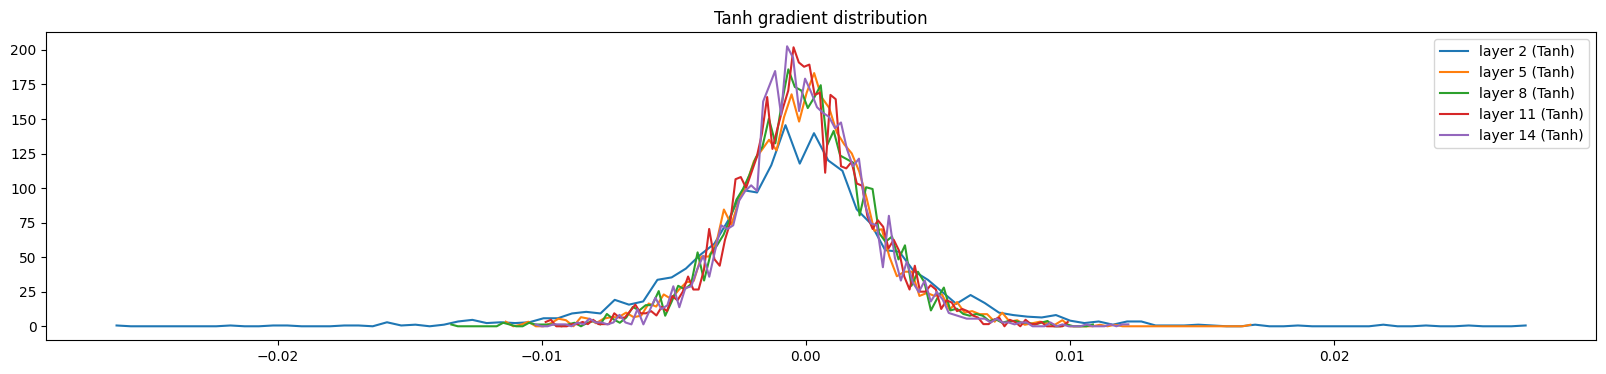

In [73]:
# Tanh Activations/Saturations
# visualize histograms
# Y axis represent probability density, Probability(Area) = density (height) * bin_size
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad # Shape [32, 100]
    layer_name = layer.__class__.__name__
    print(f"layer {i} ({layer_name}): mean:{t.mean():.2f}, std:{t.std():.2f}")
    hy, hx = torch.histogram(t, density=True) # hx (101) hy (100)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends);
plt.title('Tanh gradient distribution')


Intuition for plot above:


Think of gradients as a learning signal:

- Wide, healthy spread → strong signal ✅ (Early layers similar to later layers, good)

- All near zero → weak signal ❌

- Too large → noisy/unstable ❌


What to look for in the plot:

- Healthy → curves for all layers mostly overlap with similar width
- Vanishing → later layer curves are tall and very narrow (spike near 0), meaning gradients died before reaching them — fix with better weight init or BatchNorm
- Exploding → curves spread extremely wide — fix with gradient clipping or a lower learning rate

weight (27, 10) | mean -5.653913551331816e-19 | std 0.016297136298716004 | grad:data ratio 0.017089359210955626
weight (30, 100) | mean 0.00018590178165244235 | std 0.012801900689258652 | grad:data ratio 0.06828176582871887
weight (100, 100) | mean 4.565894180635782e-05 | std 0.008427794397478863 | grad:data ratio 0.08170299183780734
weight (100, 100) | mean 6.713536844349444e-05 | std 0.007291438471926021 | grad:data ratio 0.07094261693547041
weight (100, 100) | mean 2.019397087794911e-05 | std 0.007190617672449849 | grad:data ratio 0.07023256715126074
weight (100, 100) | mean 4.516770993839452e-05 | std 0.006883529746592761 | grad:data ratio 0.06730033934058256
weight (100, 27) | mean 4.304614276284089e-05 | std 0.014502253393208186 | grad:data ratio 0.13368179928449067


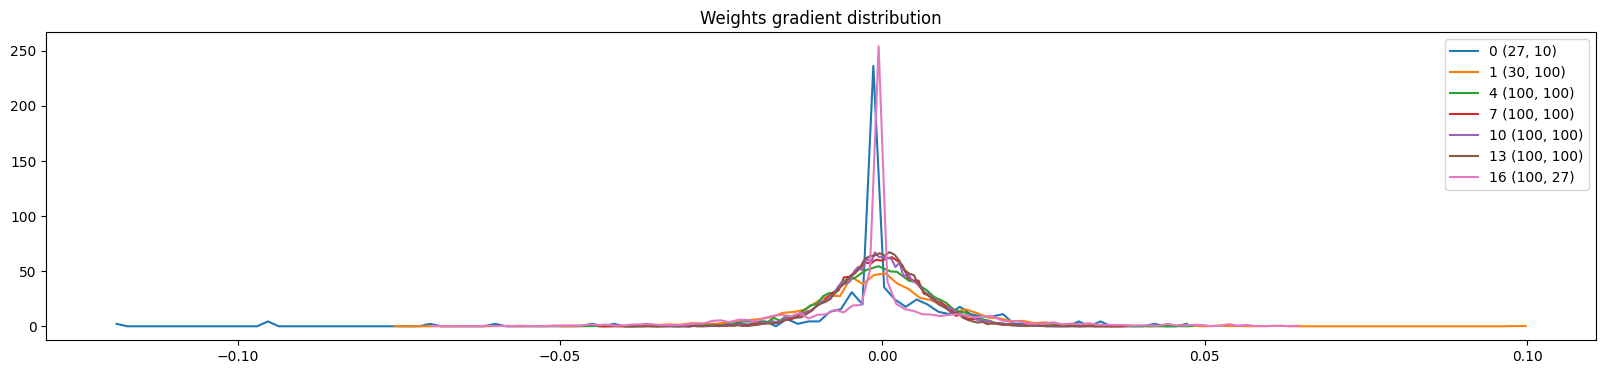

In [75]:
# Visualizing weights gradients as well

# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2 and p.shape[0] != 1: # skipping biases, gamma and beta for simplicity
    print(f"weight {tuple(p.shape)} | mean {t.mean()} | std {t.std()} | grad:data ratio {t.std()/p.std()}")
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('Weights gradient distribution');

### Grad to data ratio intuition above
~ 1e-3 to 1e-2 (updates are small but meaningful)

For example in last layer, update is happening aggressively
i.e 0.13

This should stabilize over time, else it's problematic


In [86]:
# Update to data ratio

# MLP
n_embd = 10
n_hidden = 100
vocab_size = 27
block_size = 3

layers = [
    Linear(n_embd*block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size), BatchNorm1d(vocab_size)
]
C  = torch.randn(vocab_size, n_embd, dtype=torch.float64, generator=g)


max_steps = 200_000
batch_size = 32
lossi = []

# ====================  ADDED THIS ==================================
update_to_data_ratio = []

# Setting parameters to require grad
parameters = [C] + [p for layer in layers for p in layer.parameters()]
for p in parameters:
  p.requires_grad = True

print(sum(p.nelement() for p in parameters)) # number of parameters in total

for i in range(max_steps):
  # minibatch construct
  ix = torch.randint(0, X_tr.shape[0], (batch_size,), generator=g)
  Xb, Yb = X_tr[ix], Y_tr[ix]

  emb = C[Xb]                           # [32, 3, 10]
  out = emb.view(batch_size, -1)        # [32, 30]

  for layer in layers:
    out = layer(out)
  loss = F.cross_entropy(out, Yb)

  # Backward pass
  for layer in layers:
    layer.out.retain_grad() # By default, Pytorch does not retain grads of non-params for efficiency
  for p in parameters:
    p.grad = None
  loss.backward()

  # Update
  lr = 0.1 if i < 100_000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  if i >= 1_000:
    break

  update_to_data_ratio.append([((lr*p.grad).std()/p.std()).log10().item() for p in parameters])

  if i % 10_000 == 0:
    print(f"{i}/{max_steps} : {loss.item():.4f}")
  lossi.append(loss.item())

47024
0/200000 : 3.5489


In [87]:
len(update_to_data_ratio), len(update_to_data_ratio[0])

(1000, 19)

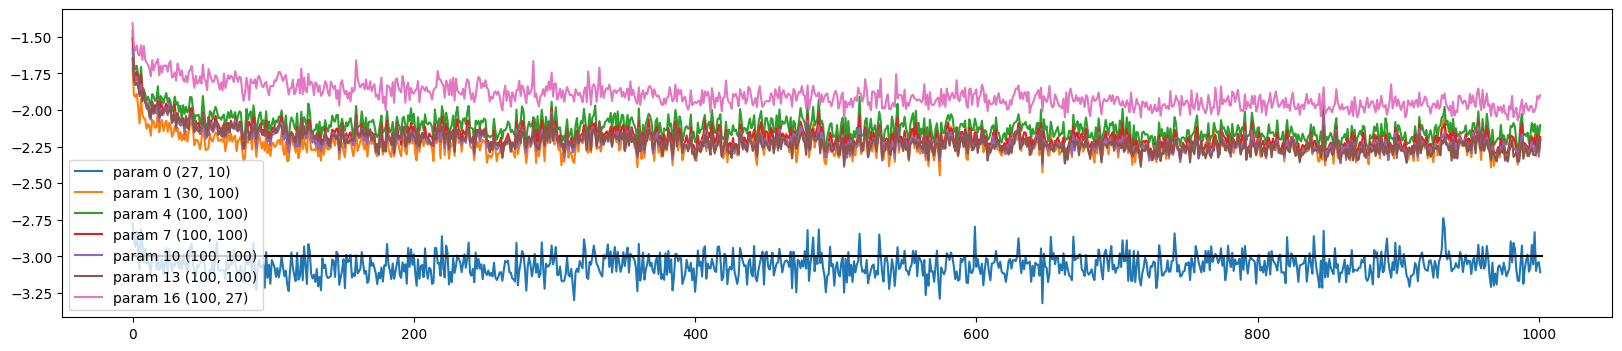

In [84]:
# X axis represents runs
# Y axis represents ratio

plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2 and p.shape[0] != 1:
    plt.plot([update_to_data_ratio[j][i] for j in range(len(update_to_data_ratio))])
    legends.append(f"param {i} {tuple(p.shape)}")
plt.plot([0, len(update_to_data_ratio)], [-3, -3], 'k') # These ratios should be ~1e-3, indicate on plot, draws black line
plt.legend(legends);

### Full training and inference with this new MLP

In [88]:
# Update to data ratio

# MLP
n_embd = 10
n_hidden = 100
vocab_size = 27
block_size = 3

layers = [
    Linear(n_embd*block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size), BatchNorm1d(vocab_size)
]
C  = torch.randn(vocab_size, n_embd, dtype=torch.float64, generator=g)

# Why no grad is needed here
# Without torch.no_grad(), PyTorch treats your weight updates as part of the model computation,
# which breaks the gradient logic and can corrupt training.
# Since we are manually updating weights here, we don't want any computation graph to build here

with torch.no_grad():
  layers[-1].gain *= 0.1 # Making softmax less confident initially
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.w *= (5/3) # Adding gain for tanh
      #(https://docs.pytorch.org/docs/stable/nn.init.html#torch.nn.init.calculate_gain)


max_steps = 50_000
batch_size = 32
lossi = []

# ====================  ADDED THIS ==================================
update_to_data_ratio = []

# Setting parameters to require grad
parameters = [C] + [p for layer in layers for p in layer.parameters()]
for p in parameters:
  p.requires_grad = True

print(sum(p.nelement() for p in parameters)) # number of parameters in total

for i in range(max_steps):
  # minibatch construct
  ix = torch.randint(0, X_tr.shape[0], (batch_size,), generator=g)
  Xb, Yb = X_tr[ix], Y_tr[ix]

  emb = C[Xb]                           # [32, 3, 10]
  out = emb.view(batch_size, -1)        # [32, 30]

  for layer in layers:
    out = layer(out)
  loss = F.cross_entropy(out, Yb)

  # Backward pass
  for layer in layers:
    layer.out.retain_grad() # By default, Pytorch does not retain grads of non-params for efficiency
  for p in parameters:
    p.grad = None
  loss.backward()

  # Update
  lr = 0.1 if i < 10_000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  update_to_data_ratio.append([((lr*p.grad).std()/p.std()).log10().item() for p in parameters])

  if i % 10_000 == 0:
    print(f"{i}/{max_steps} : {loss.item():.4f}")
  lossi.append(loss.item())

47024
0/50000 : 3.3058
10000/50000 : 2.2739
20000/50000 : 2.1611
30000/50000 : 2.1624
40000/50000 : 2.1404


In [94]:
# Add Calculate loss here

SPLITS = {
    'train': (X_tr, Y_tr),
    'val': (X_val, Y_val),
    'test': (X_test, Y_test)
}
@torch.no_grad
def calc_split_loss(split):
  X, Y = SPLITS[split]

  emb = C[X]
  out = emb.view(X.shape[0], -1)
  for layer in layers:
    out = layer(out)
  loss = F.cross_entropy(out, Y)
  print(f"Split: {split} Loss: {loss: .4f}")

# Setting training to False to use running mean and std
for layer in layers:
  if isinstance(layer, BatchNorm1d):
    layer.training = False
calc_split_loss('train')
calc_split_loss('val')

Split: train Loss:  2.1151
Split: val Loss:  2.1434


In [96]:
# Sample from model

g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      x = emb.view(emb.shape[0], -1) # concatenate the vectors
      for layer in layers:
        x = layer(x)
      logits = x
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break

    print(''.join(idx_to_char(i) for i in out)) # decode and print the generated word

carlah.
americk.
haimleigen.
cassanden.
jazhuel.
delynn.
jareei.
nellara.
chaiiv.
kaleigh.
ham.
join.
quinn.
sulie.
alianni.
watthoniearyxix.
kaellinsley.
daedo.
abette.
jaste.


### Exercise
E01: I did not get around to seeing what happens when you initialize all weights and biases to zero. Try this and train the neural net. You might think either that 1) the network trains just fine or 2) the network doesn't train at all, but actually it is 3) the network trains but only partially, and achieves a pretty bad final performance. Inspect the gradients and activations to figure out what is happening and why the network is only partially training, and what part is being trained exactly.

In [108]:
### Init with zeros

# MLP
n_embd = 10
n_hidden = 200
vocab_size = 27
block_size = 3

g = torch.Generator().manual_seed(2147483647) # for reproducibility

# params
C  = torch.randn(vocab_size, n_embd, dtype=torch.float64, generator=g)
W1 = torch.randn(n_embd*block_size, n_hidden, dtype=torch.float64, generator=g) * 0
b1 = torch.randn(n_hidden, dtype=torch.float64, generator=g) * 0
W2 = torch.randn(n_hidden, vocab_size, dtype=torch.float64, generator=g) * 0
b2 = torch.randn(vocab_size, dtype=torch.float64, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
total_params = sum([p.nelement() for p in parameters])

for param in parameters:
  param.requires_grad = True


max_steps = 200_000
batch_size = 32
lossi = []

for i in range(max_steps):
  # minibatch construct
  ix = torch.randint(0, X_tr.shape[0], (batch_size,), generator=g)
  Xb, Yb = X_tr[ix], Y_tr[ix]

  emb = C[Xb]                           # [32, 3, 10]
  embcat = emb.view(batch_size, -1)     # [32, 30]
  # Linear Layer
  hpreact = embcat @ W1 + b1            # [32, 30] @ [30, 200] -> [32, 200]
  # Non Linearity
  h = torch.tanh(hpreact)               # [32, 200]
  # Linear Layer
  logits = h @ W2 + b2                  # [32, 200] @ [200, 27] -> [32, 27]
  loss = F.cross_entropy(logits, Yb)

  # Backward pass
  h.retain_grad()
  for p in parameters:
    p.grad = None
  loss.backward()

  # Update
  lr = 0.1 if i < 100_000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  if i % 10_000 == 0:
    print(f"{i}/{max_steps} : {loss.item():.4f}")
  lossi.append(loss.item())

0/200000 : 3.2958
10000/200000 : 2.6685
20000/200000 : 3.0802
30000/200000 : 3.0099
40000/200000 : 2.6407
50000/200000 : 2.6752
60000/200000 : 2.8541
70000/200000 : 2.9302
80000/200000 : 2.6791
90000/200000 : 2.8784
100000/200000 : 3.0231
110000/200000 : 3.0895
120000/200000 : 2.7491
130000/200000 : 2.6937
140000/200000 : 2.9654
150000/200000 : 3.0189
160000/200000 : 2.8553
170000/200000 : 2.9718
180000/200000 : 2.5787
190000/200000 : 2.6822


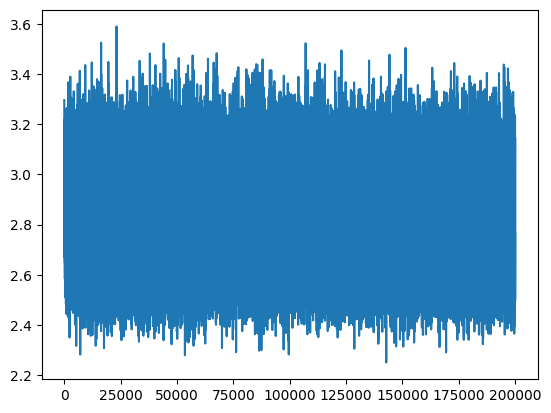

In [109]:
plt.plot(lossi)

In [110]:
SPLITS = {
    'train': (X_tr, Y_tr),
    'val': (X_val, Y_val),
    'test': (X_test, Y_test)
}
@torch.no_grad
def calc_split_loss(split):
  X, Y = SPLITS[split]

  emb = C[X]
  embcat = emb.view(X.shape[0], -1)
  hpreact = embcat @ W1 + b1
  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Y)
  print(f"Split: {split} Loss: {loss: .4f}")

calc_split_loss('train')
calc_split_loss('val')


Split: train Loss:  2.8227
Split: val Loss:  2.8210


### Inspecting visualizations

In [115]:
### Init with zeros

# MLP
n_embd = 10
n_hidden = 200
vocab_size = 27
block_size = 3

g = torch.Generator().manual_seed(2147483647) # for reproducibility

# params
C  = torch.randn(vocab_size, n_embd, dtype=torch.float64, generator=g)
W1 = torch.randn(n_embd*block_size, n_hidden, dtype=torch.float64, generator=g) * 0
b1 = torch.randn(n_hidden, dtype=torch.float64, generator=g) * 0
W2 = torch.randn(n_hidden, vocab_size, dtype=torch.float64, generator=g) * 0
b2 = torch.randn(vocab_size, dtype=torch.float64, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
total_params = sum([p.nelement() for p in parameters])

for param in parameters:
  param.requires_grad = True


max_steps = 200_000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
  # minibatch construct
  ix = torch.randint(0, X_tr.shape[0], (batch_size,), generator=g)
  Xb, Yb = X_tr[ix], Y_tr[ix]

  emb = C[Xb]                           # [32, 3, 10]
  embcat = emb.view(batch_size, -1)     # [32, 30]
  # Linear Layer
  hpreact = embcat @ W1 + b1            # [32, 30] @ [30, 200] -> [32, 200]
  # Non Linearity
  h = torch.tanh(hpreact)               # [32, 200]
  # Linear Layer
  logits = h @ W2 + b2                  # [32, 200] @ [200, 27] -> [32, 27]
  loss = F.cross_entropy(logits, Yb)

  # Backward pass
  h.retain_grad()
  for p in parameters:
    p.grad = None
  loss.backward()

  # Update
  lr = 0.1 if i < 100_000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  if i >= 10_000:
    break

  if i % 10_000 == 0:
    print(f"{i}/{max_steps} : {loss.item():.4f}")
  lossi.append(loss.item())
  ud.append([((lr*p.grad).std()/p.std()).log10().item() for p in parameters])

0/200000 : 3.2958


layer mean:0.00, std:0.00, saturated:0.00%


Text(0.5, 1.0, 'Tanh activation distribution')

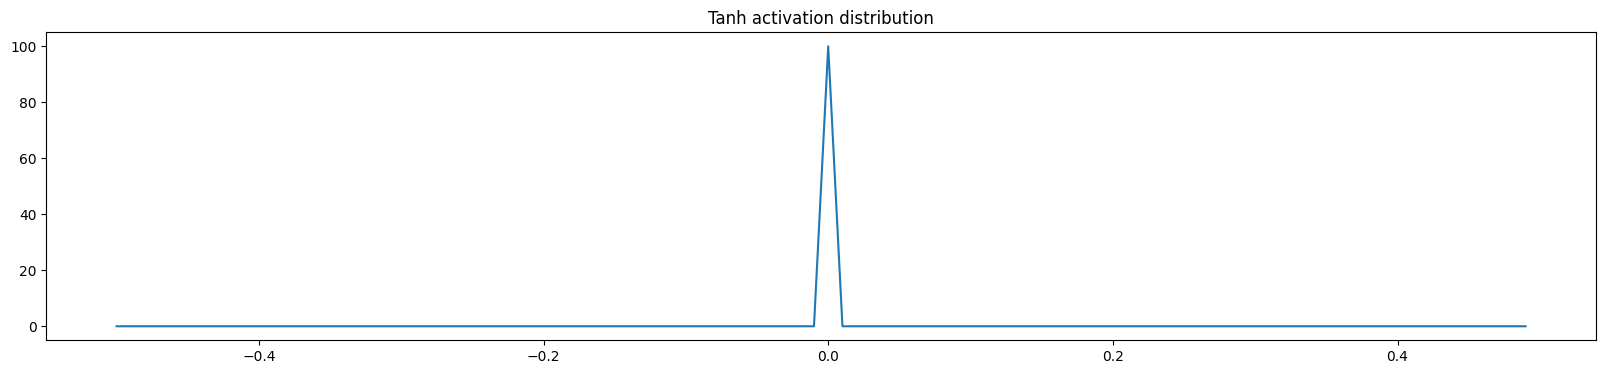

In [116]:
# Tanh Activations/Saturations
# visualize histograms
# Y axis represent probability density, Probability(Area) = density (height) * bin_size
plt.figure(figsize=(20, 4)) # width and height of the plot
saturated_percentage = ((h.abs() > 0.97).float().mean()) * 100
print(f"layer mean:{h.mean():.2f}, std:{h.std():.2f}, saturated:{saturated_percentage:.2f}%")
hy, hx = torch.histogram(h, density=True) # hx (101) hy (100)
plt.plot(hx[:-1].detach(), hy.detach())
plt.title('Tanh activation distribution')

layer mean:0.00, std:0.00


Text(0.5, 1.0, 'Tanh gradient distribution')

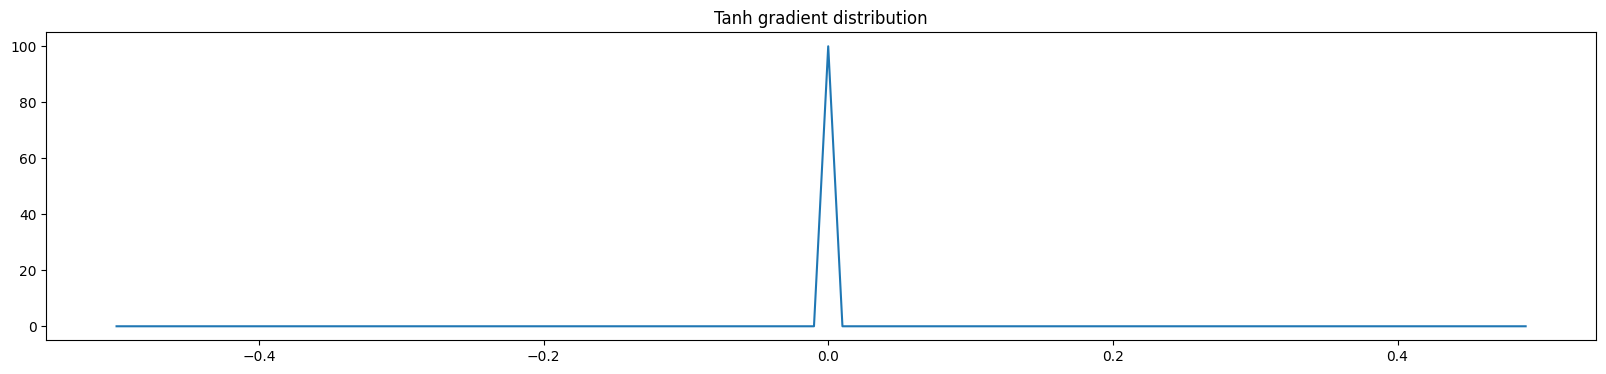

In [117]:
# Tanh gradients
# visualize histograms
# Y axis represent probability density, Probability(Area) = density (height) * bin_size
plt.figure(figsize=(20, 4)) # width and height of the plot
t = h.grad
print(f"layer mean:{t.mean():.2f}, std:{t.std():.2f}")
hy, hx = torch.histogram(t, density=True) # hx (101) hy (100)
plt.plot(hx[:-1].detach(), hy.detach())
plt.title('Tanh gradient distribution')


weight (27, 10) | mean 0.0 | std 0.0 | grad:data ratio 0.0
weight (30, 200) | mean 0.0 | std 0.0 | grad:data ratio nan
weight (200,) | mean 0.0 | std 0.0 | grad:data ratio nan
weight (200, 27) | mean 0.0 | std 0.0 | grad:data ratio nan
weight (27,) | mean 0.0 | std 0.02385342722585666 | grad:data ratio 0.01991671359429462


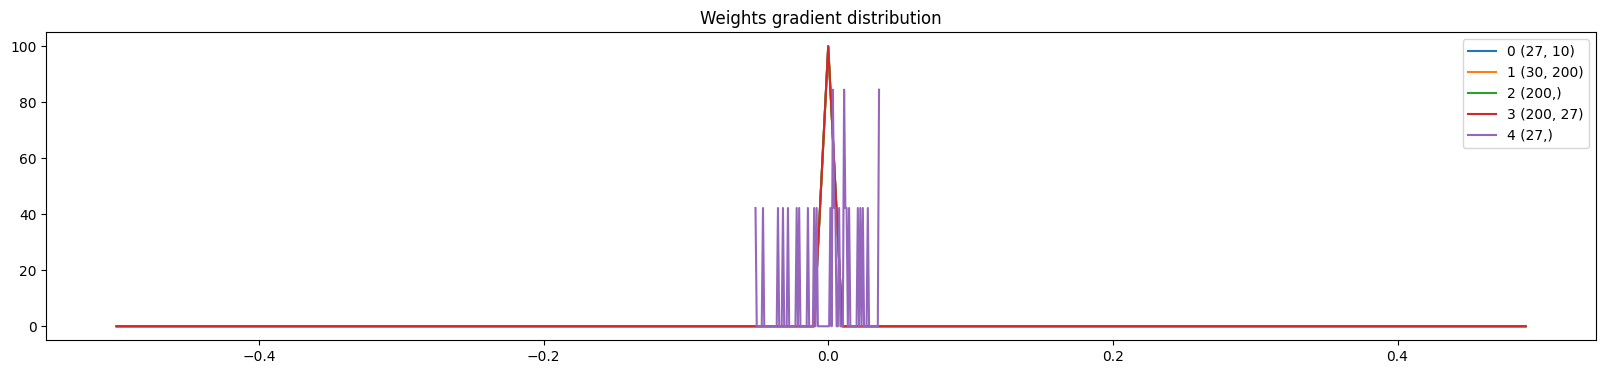

In [131]:
# Visualizing weights gradients as well

# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  print(f"weight {tuple(p.shape)} | mean {t.mean()} | std {t.std()} | grad:data ratio {t.std()/p.std()}")
  hy, hx = torch.histogram(t, density=True)
  plt.plot(hx[:-1].detach(), hy.detach())
  legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('Weights gradient distribution');

### Only b2 gradients show slight variance away from zero (0.02)

In [122]:
ud[:10]

[[-inf, nan, nan, nan, 0.0],
 [-inf, nan, nan, nan, -0.1948606117896984],
 [-inf, nan, nan, nan, -0.39125681721471334],
 [-inf, nan, nan, nan, -0.551465378533733],
 [-inf, nan, nan, nan, -0.699753010315063],
 [-inf, nan, nan, nan, -0.7204356443108161],
 [-inf, nan, nan, nan, -0.7334895987846989],
 [-inf, nan, nan, nan, -0.8729492401091214],
 [-inf, nan, nan, nan, -0.8919371750830657],
 [-inf, nan, nan, nan, -0.946584531879812]]

torch.Size([27, 10])
torch.Size([30, 200])
torch.Size([200])
torch.Size([200, 27])
torch.Size([27])


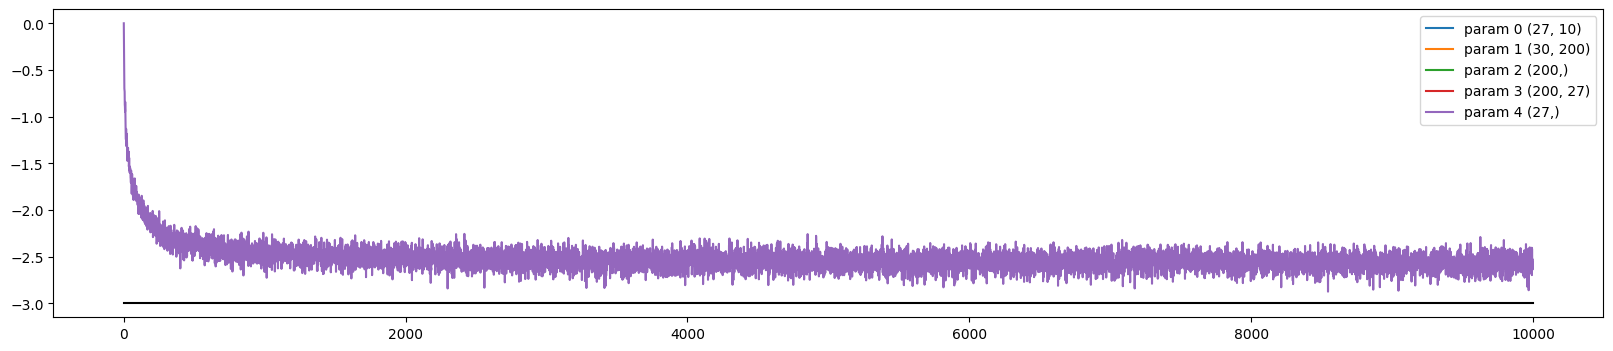

In [130]:
# X axis represents runs
# Y axis represents ratio

plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  print(p.shape)
  plt.plot([ud[j][i] for j in range(len(ud))])
  legends.append(f"param {i} {tuple(p.shape)}")
plt.plot([0, len(ud)], [-3, -3], 'k') # These ratios should be ~1e-3, indicate on plot, draws black line
plt.legend(legends);

### NOTE: Only param 4 i.e. b2 changes as its closely connected to loss function ?

In [127]:
# Inference
# Sample from model

g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd) #[1, 3, 10]

      embcat = emb.view(emb.shape[0], -1) # concatenate the vectors [1, 30]
      # Linear Layer
      hpreact = embcat @ W1 + b1            # [1, 30] @ [30, 200] -> [1, 200]
      # Non Linearity
      h = torch.tanh(hpreact)               # [1, 200]
      # Linear Layer
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)     # [1, 27]
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break

    print(''.join(idx_to_char(i) for i in out)) # decode and print the generated word

narmahxaae.
hlrihkimrs.
reaty.
hnaassnejr.
hnenfamesrhc.
iaeei.
.
ermnia.
ceaiiv.
e.
lein.
h.
.
m.
.
oin.
eeijn.
s.
lilea.
.


Other people's solutions:

https://medium.com/@douyipu/building-makemore-part-3-exercise-solutions-guide-a39548fab414

Batchnorm Vids:

https://www.youtube.com/watch?v=PaIKIXb3v9Q
